In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from torch.optim import Adam
from torch import optim
from torchvision import datasets

In [2]:
!pip install -q music21

In [3]:
!unzip chopin.zip -d chopin

Archive:  chopin.zip
replace chopin/chpn-p9.mid? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace chopin/chp_op31.mid? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: chopin/chp_op31.mid     
  inflating: chopin/chpn_op10_e01.mid  
  inflating: chopin/chpn_op10_e05.mid  
  inflating: chopin/chpn_op10_e12.mid  
  inflating: chopin/chpn_op25_e11.mid  
  inflating: chopin/chpn_op35_1.mid  
  inflating: chopin/chpn_op35_2.mid  
  inflating: chopin/chpn_op35_3.mid  
  inflating: chopin/chpn_op35_4.mid  
  inflating: chopin/chpn-p1.mid      
  inflating: chopin/chpn-p10.mid     
  inflating: chopin/chpn-p11.mid     
  inflating: chopin/chpn-p12.mid     
  inflating: chopin/chpn-p13.mid     
  inflating: chopin/chpn-p14.mid     
  inflating: chopin/chpn-p15.mid     
  inflating: chopin/chpn-p16.mid     
  inflating: chopin/chpn-p17.mid     
  inflating: chopin/chpn-p18.mid     
  inflating: chopin/chpn-p19.mid     
  inflating: chopin/chpn-p2.mid      
  inflating: chopin/chpn-p20.mid    

In [4]:
import os
import music21
import glob



def extract_notes(midi_file):
    """
    Extract notes and chords from a MIDI file

    Args:
        midi_file: Path to the MIDI file

    Returns:
        List of notes and chords
    """
    print(f"Extracting notes from: {midi_file}")

    notes = []

    midi = music21.converter.parse(midi_file)

    instruments = music21.instrument.partitionByInstrument(midi)

    if instruments:  # File has instrument parts
        for part in instruments.parts:
            # Get all notes and chords from this instrument part
            notes_to_parse = part.recurse()

            for element in notes_to_parse:
                if isinstance(element, music21.note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, music21.chord.Chord):
                    notes.append('.'.join(str(n) for n in element.normalOrder))
    else:
        notes_to_parse = midi.flat.notes

        for element in notes_to_parse:
            if isinstance(element, music21.note.Note):
                notes.append(str(element.pitch))
            elif isinstance(element, music21.chord.Chord):
                notes.append('.'.join(str(n) for n in element.normalOrder))

    return notes

def preprocess_data():
    chopin_midi_dir = "./chopin"

    if not os.path.exists(chopin_midi_dir):
        os.makedirs(chopin_midi_dir)
        print(f"Please place Chopin's MIDI files in the '{chopin_midi_dir}' directory and run the script again.")
        return

    # Get all MIDI files in the directory
    midi_files = glob.glob(f"{chopin_midi_dir}/*.mid")

    if not midi_files:
        print(f"\nNo MIDI files found in '{chopin_midi_dir}' directory.")
        return

    all_pieces_notes = {}

    print("\nExtracting notes from MIDI files:")
    for midi_file in midi_files:
        file_name = os.path.basename(midi_file)
        notes = extract_notes(midi_file)
        all_pieces_notes[file_name] = notes
        print(f"  - {file_name}: Extracted {len(notes)} notes/chords")

    print(f"\nProcessed {len(midi_files)} Chopin MIDI files.")
    total_notes = sum(len(notes) for notes in all_pieces_notes.values())
    print(f"Total notes and chords extracted: {total_notes}")

    # Print a sample of notes from the first piece (if available)
    if all_pieces_notes:
        first_piece = list(all_pieces_notes.keys())[0]
        sample_size = min(10, len(all_pieces_notes[first_piece]))
        print(f"\nSample of notes from '{first_piece}':")
        for i, note in enumerate(all_pieces_notes[first_piece][:sample_size]):
            print(f"  {i+1}. {note}")
    return all_pieces_notes

all_pieces_notes = preprocess_data()

# extracting sequences



Extracting notes from MIDI files:
Extracting notes from: ./chopin/chpn-p1.mid
  - chpn-p1.mid: Extracted 212 notes/chords
Extracting notes from: ./chopin/chpn_op10_e12.mid
  - chpn_op10_e12.mid: Extracted 1206 notes/chords
Extracting notes from: ./chopin/chpn-p5.mid
  - chpn-p5.mid: Extracted 440 notes/chords
Extracting notes from: ./chopin/chpn-p7.mid
  - chpn-p7.mid: Extracted 85 notes/chords
Extracting notes from: ./chopin/chpn-p23.mid
  - chpn-p23.mid: Extracted 488 notes/chords
Extracting notes from: ./chopin/chpn-p12.mid
  - chpn-p12.mid: Extracted 667 notes/chords
Extracting notes from: ./chopin/chpn_op10_e01.mid
  - chpn_op10_e01.mid: Extracted 1311 notes/chords
Extracting notes from: ./chopin/chpn-p24.mid
  - chpn-p24.mid: Extracted 1060 notes/chords
Extracting notes from: ./chopin/chpn-p10.mid
  - chpn-p10.mid: Extracted 183 notes/chords
Extracting notes from: ./chopin/chpn_op33_4.mid
  - chpn_op33_4.mid: Extracted 1480 notes/chords
Extracting notes from: ./chopin/chpn-p6.mi

In [5]:
from collections import Counter


def process_notes_for_training(all_pieces_notes, min_occurrences=4, sequence_length=40):

    corpus = []
    for piece_name, notes in all_pieces_notes.items():
        corpus.extend(notes)
    print(f"Total notes in corpus: {len(corpus)}")

    note_counter = Counter(corpus)
    print(f"Total unique notes/chords before filtering: {len(note_counter)}")

    # filter notes base on the occurences
    filtered_corpus = [note for note in corpus if note_counter[note] >= min_occurrences ]
    print(f"Corpus size after filtering: {len(filtered_corpus)}")


    # sort and unique the filtered corpous
    unique_notes = sorted(set(filtered_corpus))
    print(f"Total unique notes/chords after filtering: {len(unique_notes)}")

    # creating mapping dictionary
    int_to_note = {i: note for i, note in enumerate(unique_notes)}
    note_to_int = {note: i for i, note in enumerate(unique_notes)}

    #creating sequence
    labels = []
    sequences = []
    for i in range(0, len(filtered_corpus) - sequence_length):
      sequence = filtered_corpus[i: i + sequence_length]
      label = filtered_corpus[i + sequence_length]
      sequence = [note_to_int[note] for note in sequence]
      label = note_to_int[label]
      sequences.append(sequence)
      labels.append(label)
    print(f"Created {len(sequences)} sequences for training")



    # Prepare final training data
    n_vocab = len(unique_notes)

    # Reshape sequences for LSTM input [samples, time steps, features]
    network_input = np.reshape(sequences, (len(sequences), sequence_length, 1))

    # Normalize sequences -> because dataset contains number between 0 till n_vocab-1
    # by devide it to the n_vocab, we would take it to the range of 0 till 1
    network_input = network_input / float(n_vocab)

    # Make one hot vector for label
    network_output = F.one_hot(torch.tensor(labels), num_classes=n_vocab)

    print("Training data preparation complete!")
    print(f"Input shape: {network_input.shape}")
    print(f"Output shape: {network_output.shape}")

    return network_input, network_output, note_to_int, int_to_note


network_input, network_output, note_to_int, int_to_note = process_notes_for_training(
        all_pieces_notes,
        min_occurrences=4,
        sequence_length=40
    )

Total notes in corpus: 57894
Total unique notes/chords before filtering: 397
Corpus size after filtering: 57692
Total unique notes/chords after filtering: 280
Created 57652 sequences for training
Training data preparation complete!
Input shape: (57652, 40, 1)
Output shape: torch.Size([57652, 280])


In [6]:
import pickle

def save_processed_data(network_input, network_output, note_to_int, int_to_note, output_dir="./processed_data"):
   """
    Save processed data to disk

    Args:
        network_input: Encoded input sequences
        network_output: One-hot encoded output labels
        note_to_int: Dictionary mapping notes to integers
        int_to_note: Dictionary mapping integers to notes
        output_dir: Directory to save the data
   """

   if not os.path.exists(output_dir):
      os.makedirs(output_dir)
   np.save(f"{output_dir}/network_input.npy", network_input)
   np.save(f"{output_dir}/network_output.npy", network_output)

   with open(f"{output_dir}/note_to_int.pkl", "wb") as f:
    pickle.dump(note_to_int, f)
   with open(f"{output_dir}/int_to_note.pkl", "wb") as f:
    pickle.dump(int_to_note, f)


save_processed_data(network_input, network_output, note_to_int, int_to_note)

In [7]:
torch.manual_seed(42)
np.random.seed(42)

In [8]:
from torch.utils.data import DataLoader, TensorDataset, random_split
def pretrain_dataset(network_input, network_output, test_size=0.2,
                     batch_size=64):

  # Convert input to the torch from numpy and make dataset
  network_input = torch.tensor(network_input, dtype=torch.float32)
  dataset = TensorDataset(network_input, network_output)

  # Specify the size of test and train
  dataset_size = len(dataset)
  test_size = int(dataset_size * test_size)
  train_size = dataset_size - test_size

  print(f"Total samples: {dataset_size}")
  print(f"Training samples: {train_size}")
  print(f"Testing samples: {test_size}")

  # split, and dataloader
  train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
  train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
  test_loader = DataLoader(test_dataset, shuffle=True, batch_size=batch_size)

  return train_loader, test_loader


In [9]:
class MusicLSTM(nn.Module):
    """
    LSTM model for music generation based on the provided architecture
    """
    def __init__(self, input_size, output_size):
        super().__init__()

        # First LSTM layer with 512 units
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=512,
            batch_first=True
        )

        # Second LSTM layer with 256 units
        self.lstm2 = nn.LSTM(
            input_size=512,
            hidden_size=256,
            batch_first=True
        )

        # First Dense layer with 256 units
        self.dense1 = nn.Linear(256, 256)

        # Second Dense layer with output_size units (matches your n_vocab)
        # The image shows 266 units but this should match your vocabulary size
        self.dense2 = nn.Linear(256, output_size)

    def forward(self, x):
        # First LSTM layer
        lstm1_out, _ = self.lstm1(x)

        # Second LSTM layer (use only the output from the last time step)
        lstm2_out, _ = self.lstm2(lstm1_out)
        lstm2_out = lstm2_out[:, -1, :]  # Take only the last time step

        # First Dense layer with ReLU activation
        dense1_out = F.relu(self.dense1(lstm2_out))

        # Second Dense layer (softmax will be applied in loss function or during prediction)
        output = self.dense2(dense1_out)

        return output

In [10]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    """
    Train the model

    Args:
        model: PyTorch model
        train_loader: Training data loader
        test_loader: Testing data loader
        criterion: Loss function
        optimizer: Optimizer
        num_epochs: Number of training epochs
        device: Device to train on (CPU or CUDA)

    Returns:
        model: Trained model
        history: Dictionary containing training history
    """
    model = model.to(device)

    # For tracking metrics
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_accuracy': []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # For CrossEntropyLoss, we need class indices, not one-hot
            if isinstance(criterion, nn.CrossEntropyLoss):
                target_indices = torch.argmax(targets, dim=1)
                loss = criterion(outputs, target_indices)
            else:
                loss = criterion(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        # Average training loss
        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        # Testing
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                # Forward pass
                outputs = model(inputs)

                # For CrossEntropyLoss, we need class indices, not one-hot
                if isinstance(criterion, nn.CrossEntropyLoss):
                    target_indices = torch.argmax(targets, dim=1)
                    loss = criterion(outputs, target_indices)

                    # Calculate accuracy
                    _, predicted = torch.max(outputs, 1)
                    correct += (predicted == target_indices).sum().item()
                else:
                    loss = criterion(outputs, targets)

                    # Calculate accuracy
                    _, predicted = torch.max(outputs, 1)
                    _, target_indices = torch.max(targets, 1)
                    correct += (predicted == target_indices).sum().item()

                test_loss += loss.item() * inputs.size(0)
                total += targets.size(0)

        # Average test loss and accuracy
        test_loss = test_loss / len(test_loader.dataset)
        test_accuracy = correct / total

        history['test_loss'].append(test_loss)
        history['test_accuracy'].append(test_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, '
              f'Test Accuracy: {test_accuracy:.4f}')

    return model, history

In [11]:
def plot_training_history(history):
    """
    Plot training history

    Args:
        history: Dictionary containing training history
    """
    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['test_loss'], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Test Loss')

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['test_accuracy'], label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Test Accuracy')

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

def generate_music(model, seed_sequence, int_to_note, sequence_length, n_vocab, num_notes=100):
    """
    Generate music using the trained model

    Args:
        model: Trained PyTorch model
        seed_sequence: Initial sequence to start generation
        int_to_note: Dictionary mapping integers to notes
        sequence_length: Length of input sequences
        n_vocab: Size of vocabulary
        num_notes: Number of notes to generate

    Returns:
        Generated notes
    """
    model.eval()

    # Create initial sequence
    current_sequence = seed_sequence
    generated_notes = []

    # Device
    device = next(model.parameters()).device

    # Generate notes
    for _ in range(num_notes):
        # Prepare input
        sequence = np.reshape(current_sequence, (1, sequence_length, 1))
        sequence = sequence / float(n_vocab)
        sequence = torch.tensor(sequence, dtype=torch.float32).to(device)

        # Predict next note
        with torch.no_grad():
            prediction = model(sequence)

        # Apply softmax to get probabilities
        probabilities = F.softmax(prediction, dim=1).cpu().numpy()[0]

        # Sample from the distribution
        best_note_index = np.random.choice(range(len(probabilities)), p=probabilities)

        # Get the corresponding note
        best_note = int_to_note[best_note_index]
        generated_notes.append(best_note)

        # Update the sequence
        current_sequence = np.append(current_sequence[1:], [[best_note_index]], axis=0)

    return generated_notes


In [ ]:

def fix_lstm_module():
    """
    Fix for the nn.LSTM module in PyTorch which doesn't have return_sequences parameter
    """
    # Original LSTM forward
    original_lstm_forward = nn.LSTM.forward

    # Define a new forward method
    def new_lstm_forward(self, *args, **kwargs):
        output, hidden = original_lstm_forward(self, *args, **kwargs)
        import pdb;pdb.set_trace()
        if hasattr(self, 'return_sequences') and not self.return_sequences:
            return output[:, -1, :], hidden
        return output, hidden

    # Add the return_sequences attribute to the LSTM class
    setattr(nn.LSTM, 'return_sequences', False)


    # Replace the forward method with the new one
    setattr(nn.LSTM, 'forward', new_lstm_forward)






In [14]:
import torch
type(torch.tensor([1,2,3], dtype=torch.float32).ndim)

int

In [17]:
original_lstm_forward = nn.LSTM.forward
def new_lstm_forward(self, *args, **kwargs):
    output, hidden = original_lstm_forward(self, *args, **kwargs)
    if hasattr(self, 'return_sequences') and not self.return_sequences \
    and output.ndim==3:
        return output[:, -1, :], hidden
    return output, hidden


# Add the return_sequences attribute to the LSTM class
setattr(nn.LSTM, 'return_sequences', False)


# Replace the forward method with the new one
setattr(nn.LSTM, 'forward', new_lstm_forward)

Total samples: 57652
Training samples: 46122
Testing samples: 11530
Model Architecture:
MusicLSTM(
  (lstm1): LSTM(1, 512, batch_first=True)
  (lstm2): LSTM(512, 256, batch_first=True)
  (dense1): Linear(in_features=256, out_features=256, bias=True)
  (dense2): Linear(in_features=256, out_features=280, bias=True)
)
Total parameters: 1980952
Using device: cuda
Starting training...
Epoch 1/50, Train Loss: 4.9242, Test Loss: 4.9079, Test Accuracy: 0.0295
Epoch 2/50, Train Loss: 4.9001, Test Loss: 4.8991, Test Accuracy: 0.0295
Epoch 3/50, Train Loss: 4.8977, Test Loss: 4.9003, Test Accuracy: 0.0203
Epoch 4/50, Train Loss: 4.8953, Test Loss: 4.9191, Test Accuracy: 0.0295
Epoch 5/50, Train Loss: 4.8942, Test Loss: 4.8945, Test Accuracy: 0.0295
Epoch 6/50, Train Loss: 4.8934, Test Loss: 4.8950, Test Accuracy: 0.0295
Epoch 7/50, Train Loss: 4.8921, Test Loss: 4.8949, Test Accuracy: 0.0295
Epoch 8/50, Train Loss: 4.8910, Test Loss: 4.8963, Test Accuracy: 0.0295
Epoch 9/50, Train Loss: 4.8902, T

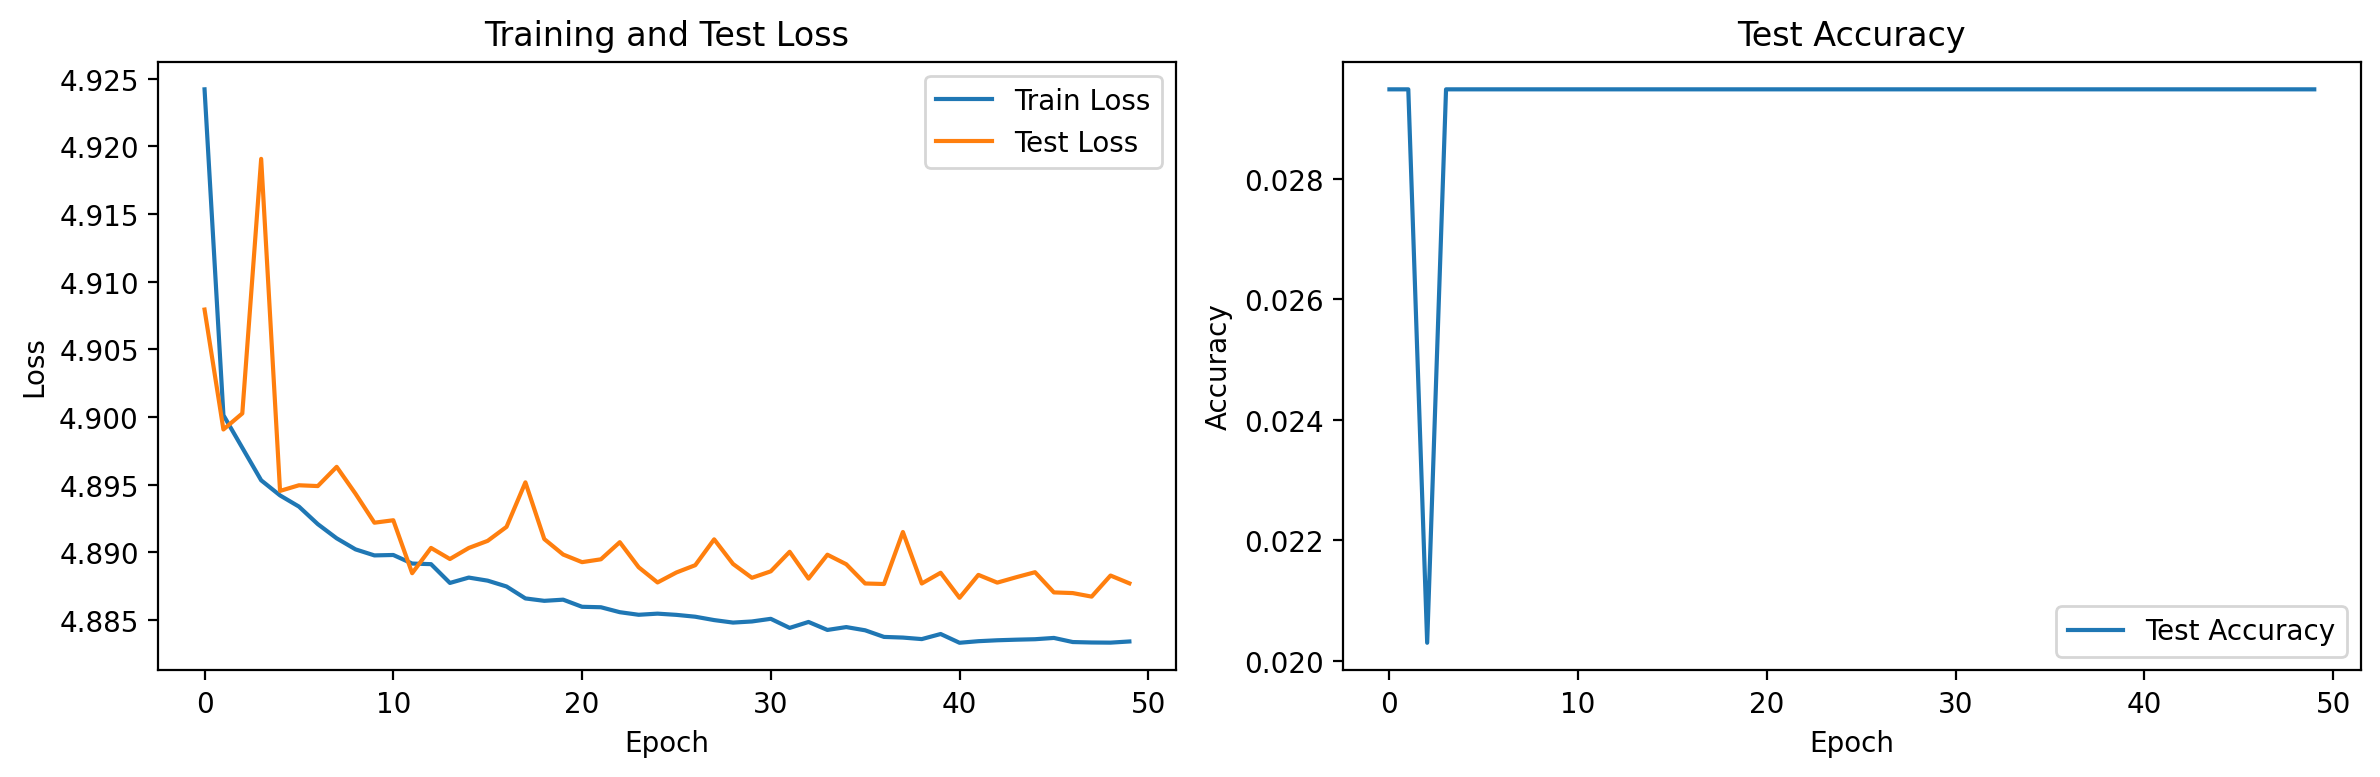

Model saved as 'music_generator_model.pth'
Generating sample music...
Sample of generated notes:
['0.5.6', 'D3', '8.0', 'C#3', 'G#3', '5.9', 'B-2', 'E5', '5.10', '10']
Generated music saved to 'generated_music.txt'


In [13]:

# Fix nn.LSTM to support return_sequences parameter
# fix_lstm_module()


# Split data into train and test sets
train_loader, test_loader = pretrain_dataset(
    network_input,
    network_output,
    test_size=0.2,
    batch_size=64
)

# Get parameters
sequence_length = network_input.shape[1]
n_vocab = network_output.shape[1]

# Initialize model with architecture from the image
model = MusicLSTM(
    input_size=1,       # Single feature (note index)
    output_size=n_vocab # Size of output (vocabulary size)
)

# Print model summary to confirm architecture
print("Model Architecture:")
print(model)

# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Choose loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train model
print("Starting training...")
model, history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    num_epochs=50,
    device=device
)

# Plot training history
plot_training_history(history)

# Save model
torch.save(model.state_dict(), 'music_generator_model.pth')
print("Model saved as 'music_generator_model.pth'")

# Generate sample music
print("Generating sample music...")
# Get a random seed sequence from the test set
seed_sequence = network_input[0]
seed_sequence = seed_sequence.reshape((sequence_length, 1))

generated_notes = generate_music(
    model,
    seed_sequence,
    int_to_note,
    sequence_length,
    n_vocab,
    num_notes=100
)

print("Sample of generated notes:")
print(generated_notes[:10])

# Save generated notes to a file
with open('generated_music.txt', 'w') as f:
    for note in generated_notes:
        f.write(f"{note}\n")


print("Generated music saved to 'generated_music.txt'")

# return model, history, generated_notes
